# Schema di Corruzione Dataset

In [56]:
import pandas as pd
import numpy as np
import os
import hashlib
from scipy import optimize
import torch
# Configurazione dei dataset da processare
DATASETS = [
    {
        'name': 'heloc_ML',
        'test_file_full': '../../data/processed/Fase2/SplitDataset/Split_ML/heloc_ML_imputation_test.csv',
        'test_file_mask': '../../data/processed/Fase2/SplitDataset/Split_ML/heloc_ML_imputation_test_no_boolean.csv',
        'out_dir': '../../data/processed/Fase2/DataCorruption/heloc_ML'
    },
    {
        'name': 'heloc_DLLM',
        'test_file_full': '../../data/processed/Fase2/SplitDataset/Split_DLLM/heloc_DLLM_imputation_test.csv',
        'test_file_mask': '../../data/processed/Fase2/SplitDataset/Split_DLLM/heloc_DLLM_imputation_test.csv',
        'out_dir': '../../data/processed/Fase2/DataCorruption/heloc_DLLM'
    }
]

TARGET_COL = 'RiskPerformance'
STRATEGIES = ['MCAR', 'MAR', 'MNAR']
PERCENTAGES = [0.10, 0.25, 0.40]
SEED = 42



In [57]:
#funzione per calcolare la media ignorando i NaN
def nanmean(v, *args, **kwargs):
    v = v.clone()
    is_nan = torch.isnan(v)
    v[is_nan] = 0
    return v.sum(*args, **kwargs) / (~is_nan).float().sum(*args, **kwargs)
    


#funzione per creare il seed deterministico usando MD5
def get_deterministic_seed(input_string):
    hash_object = hashlib.md5(input_string.encode())
    #converte la stringa hash in un esadecimale prendendo i primi 8 caratteri e la converte in un intero
    seed = int(hash_object.hexdigest() [:8], 16) % (2 ** 31)
    return seed

#converte le stringhe in NaN per poterle gestire allo stesso modo delle variabili numeriche
def convert_strings_to_nan(X):
    X_out = np.empty(X.shape, dtype=float)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            try:
                X_out[i, j] = float(X[i, j])
            except (ValueError, TypeError):
                X_out[i, j] = np.nan
    return X_out

In [58]:
#imputa temporaneamente i NaN con al media per fare il calcolo della sigmoide.
def impute_nans(X):
    means = nanmean(X,0)
    X_imputed = X.clone()
    mask = torch.isnan(X_imputed)
    X_imputed[mask] = (mask * means)[mask]
    return X_imputed


In [59]:
#funzione per la corruzione MCAR
#prende in input X = tensore con i dati, p = percentuale di dati mancanti da introdurre, p_obs = percentuale di feature osservabili (non corrotte)
#la funzione divide in due gruppi il dataset, un gruppo di feature che rimangono osservabili e un gruppo di feature che vengono corrotte, mantenendo quella che è la probabilità richiesta 
#e corrompendo le variabili in modo casuale, restituisce la maschera dove true è il valore mancante

def corrupt_mcar(X, p, p_obs):
    n, d = X.shape
    
    #controlla se l'input è un tensore torch o un numpy array
    to_torch = torch.is_tensor(X)
    if not to_torch:
        X = torch.from_numpy(X)  # converte a torch se necessario
    
    #se True allora il valore è mancante di base se false è osservabile di base
    mask_observable = torch.isnan(X)

    #calcola il numero totale di celle
    total_cells = n * d
    #calcola quante celle target corrispondere al p% richiesto sul dataset intero
    target_artificial_cells = int(p * total_cells)
    #calcola il numero di celle osservabili (non già NaN)
    observable_cells = (~mask_observable).float().sum().item()
    #adatta la probabilità per raggiungere il target sulle sole celle osservabili
    p_adjusted = target_artificial_cells / observable_cells if observable_cells > 0 else p

    #inizializza la maschera vuota (sempre torch internamente)
    mask = torch.zeros(n, d, dtype=torch.bool)
    #calcola le colonne che devono rimanere osservabili (minimo una)
    d_obs = max(int(p_obs * d), 1)
    
    d_na = d - d_obs

    #selezione casualmente quali colonne rimangono osservabili
    idxs_obs = np.random.choice(d, d_obs, replace=False)
    #seleziona le colonne che devono essere corrotte
    idxs_nas = np.array([i for i in range(d) if i not in idxs_obs])

    #genera una matrice di numeri casuali tra 0 e 1 per le colonne da corrompere
    #in pratica è un trucco, serve per mantenere la casualità della corruzione ma garantendo il vincolo della percentuale di corruzione
    ber = torch.rand(n, d_na)

    #Applica la corruzione solo sulle celle osservate (non già NaN)
    #usa p_adjusted che è la probabilità adattata per il target richiesto
    for j_idx, j in enumerate(idxs_nas):
        mask[:,j] = (~mask_observable[:,j]) & (ber[:, j_idx] < p_adjusted)
    
    if to_torch:
        return mask
    else:
        return mask.numpy().astype(bool)

In [60]:
#funzione per la corruzione MAR
#introduce dei dati mancanti che dipendono direttamente da altre variabili tramite la regressione logistica
#1. seleziona 30% delle feature come anchor (prima di essere corrotte)
#2. per il 70% colonne rimanenti la probabilità di essere NaN dipende dai valori degli anchor
#3. Usa un modello logistico: P(NaN in 70%) = sigmoid(X_anchor * w + b) dove w e b sono i pesi e bias del modello.
#4. Confronta p con un numero casuale e se random < p allora la cella diventa NaN

#genera coefficienti casuali per la regressione logistica
#normalizza per la varianza unitaria per evitare che sia troppo piccola rendendo l'argomento della sigmoide vicino a 0 
#e appiattendo la curva al centro ritornando probabilità tutte di 0.5 e facendo quindi degenerare MAR in MCAR
def pick_coeffs(X, idxs_obs, idxs_nas):
    d_obs = len(idxs_obs)
    d_na = len(idxs_nas)

    X_imputed = impute_nans(X)

    #genera coefficienti casuali per la regressione logistica
    coeffs = torch.randn(d_obs, d_na, dtype=X.dtype)

    #calcola il prodotto X_anchor * w + b
    Wx = X_imputed[:, idxs_obs].mm(coeffs)

    #normalizza per la varianza unitaria
    #dim calcola la deviazione standard lungo le righe per ogni colonna
    #keepdim mantiene le dimensioni originali per poter fare l'operazione di divisione
    coeffs /= torch.std(Wx, dim = 0, keepdim = True)

    return coeffs


#calcola gli intercepts (i bias) per la regressione logistica per ottenere la percentuale di NaN desiderata
def fit_intercepts(X, coeffs, p):
    d_na = coeffs.shape[1]
    intercepts = torch.zeros(d_na, dtype=X.dtype)

    X_imputed = impute_nans(X)

    for j in range(d_na):
        #funzione obiettivo per ottimizzare l'intersept 
        def funz(x):
            #praticamente applica la formula sigmoid(X_anchor * w + b)
            return torch.sigmoid(X_imputed.mv(coeffs[:, j]) + x).mean().item() - p
        intercepts[j] = optimize.bisect(funz, -50, 50)
    return intercepts


def corrupt_mar(X, p, p_obs):
    n, d = X.shape

    #controlla se l'input è un tensore torch o un numpy array
    to_torch = torch.is_tensor(X)
    if not to_torch:
        X = torch.from_numpy(X)  # converte a torch se necessario

    #calcola il numero totale di celle
    total_cells = n * d
    #calcola quante celle target corrispondere al p% richiesto sul dataset intero
    target_artificial_cells = int(p * total_cells)
    #stessa logica di MCAR per calcolare la percentuale di dati osservabili preesistenti
    mask_observable = torch.isnan(X)
    #calcola il numero di celle osservabili (non già NaN)
    observable_cells = (~mask_observable).float().sum().item()
    #adatta la probabilità per raggiungere il target sulle sole celle osservabili
    p_adjusted = target_artificial_cells / observable_cells if observable_cells > 0 else p

    #inizializza la maschera (sempre torch internamente)
    mask = torch.zeros(n, d, dtype=torch.bool)

    d_obs = max(int(p_obs * d), 1)
    
    d_na = d - d_obs

    #selezione casualmente quali colonne rimangono osservabili
    idxs_obs = np.random.choice(d, d_obs, replace=False)
    #seleziona le colonne che devono essere corrotte
    idxs_nas = np.array([i for i in range(d) if i not in idxs_obs])
    #genera i coefficienti per la regressione logistica
    coeffs = pick_coeffs(X, idxs_obs, idxs_nas)
    #calcola gli intercepts usando la probabilità adattata al target richiesto
    intercepts = fit_intercepts(X[:, idxs_obs], coeffs, p_adjusted)
    #calcola le probabilità di essere NaN per ogni cella da corrompere usando la formula sigmoid(X_anchor * w + b)
    ps = torch.sigmoid(X[:, idxs_obs].mm(coeffs) + intercepts)
    #stessa logica di MCAR per generare i numeri random per il confronto
    ber = torch.rand(n, d_na)
    for j_idx, j in enumerate(idxs_nas):
        mask[:,j] = (~mask_observable[:,j]) & (ber[:, j_idx] < ps[:, j_idx])
    
    #ritorna il tipo originale (torch o numpy)
    if to_torch:
        return mask
    else:
        return mask.numpy().astype(bool)

In [61]:
#funzione per la corruzione MNAR logistic 
#introduce dati mancanti che dipendono dai valori stessi delle variabili target
#1. seleziona 30% delle feature come anchor (rimangono pure durante il calcolo)
#2. per il 70% colonne rimanenti (na) la probabilità di essere NaN dipende dai valori degli anchor
#3. usa un modello logistico: P(NaN in na) = sigmoid(X_anchor * W + b)
#4. dopo il calcolo, applica MCAR anche agli anchor per renderli non pure

#prende in input X = tensore dei dati, p = percentuale di dati mancanti da introdurre, p_params = percentuale di feature anchor
#usando exclude_inputs = True esclude le feature anchor dal processo di corruzione, altrimenti anche le feature anchor possono essere corrotte
def corrupt_mnar(X, p, p_params  = 0.3, exclude_inputs = True):
    n, d = X.shape
    #controlla se l'input è un tensore torch o un numpy array
    to_torch = torch.is_tensor(X)
    if not to_torch:
        X = torch.from_numpy(X)  # converte a torch se necessario
    #calcola il numero totale di celle
    total_cells = n * d
    #calcola quante celle target corrispondere al p% richiesto sul dataset intero
    target_artificial_cells = int(p * total_cells)
    #calcola la percentuale di dati osservabili preesistenti
    mask_observable = torch.isnan(X)
    #calcola il numero di celle osservabili (non già NaN)
    observable_cells = (~mask_observable).float().sum().item()
    #adatta la probabilità per raggiungere il target sulle sole celle osservabili
    p_adjusted = target_artificial_cells / observable_cells if observable_cells > 0 else p

    mask = torch.zeros(n, d, dtype=torch.bool)

    #numero di variabili usate come anchor
    d_params = max(int(p_params * d), 1) if exclude_inputs else d

    d_na = d - d_params if exclude_inputs else d

    #selezione casualmente le feature anchor
    idxs_obs = np.random.choice(d, d_params, replace=False) if exclude_inputs else np.arange(d)
    #seleziona le feature da corrompere
    idxs_nas = np.array([i for i in range(d) if i not in idxs_obs]) if exclude_inputs else np.arange(d)

    #genera coefficienti casuali per la regressione logistica
    coeffs = pick_coeffs(X, idxs_obs, idxs_nas)
    #calcola gli intercepts usando la probabilità adattata al target richiesto
    intercepts = fit_intercepts(X[:, idxs_obs], coeffs, p_adjusted)
    ps = torch.sigmoid(X[:, idxs_obs].mm(coeffs) + intercepts)

    ber = torch.rand(n, d_na)
    for j_idx, j in enumerate(idxs_nas):
        mask[:, j] = (~mask_observable[:, j]) & (ber[:, j_idx] < ps[:, j_idx])
    
    #Dopo il calcolo di MNAR sul 70% esegue MCAR sul 30% se exclude_inputs = True
    if exclude_inputs:
        ber_params = torch.rand(n, d_params)
        for j_idx, j in enumerate(idxs_obs):
            #applica la probabilità adattata anche ai parametri
            mask[:, j] = (~mask_observable[:, j]) & (ber_params[:, j_idx] < p_adjusted)
    if to_torch:
        return mask
    else:
        return mask.numpy().astype(bool)

In [62]:
#loop che utilizza le funzioni di corruzione per ogni dataset e genera i file di output per ogni strategia
#genera il file di log

LOG_DIR = '../../data/processed/Fase2/DataCorruption'
run_log = []

for dataset in DATASETS:
    dataset_name = dataset['name']
    test_file_full = dataset['test_file_full']
    test_file_mask = dataset['test_file_mask']
    out_dir = dataset['out_dir']
    
    os.makedirs(out_dir, exist_ok=True)
    
    # Carica il dataset completo (con colonne booleane per ML)
    df_full = pd.read_csv(test_file_full)
    y = df_full[TARGET_COL].values
    
    # Carica il dataset per il calcolo della maschera (senza booleane per ML, completo per DLLM)
    df_mask_calc = pd.read_csv(test_file_mask)
    X = df_mask_calc.drop(columns=[TARGET_COL]).values
    X = convert_strings_to_nan(X)
    
    # Colonne non booleane per il dataset pieno
    columns_mask_calc = list(df_mask_calc.drop(columns=[TARGET_COL]).columns)
    
    for strategy in STRATEGIES:
        for percentage in PERCENTAGES:
            seed_input = f"{dataset_name}_{strategy}_{percentage}"
            seed_offset = get_deterministic_seed(seed_input) % 10000
            final_seed = SEED + seed_offset
            
            np.random.seed(final_seed)
            torch.manual_seed(final_seed)
            
            if strategy == 'MCAR':
                mask = corrupt_mcar(X, percentage, p_obs=0.3)
            elif strategy == 'MAR':
                mask = corrupt_mar(X, percentage, p_obs=0.2)
            elif strategy == 'MNAR':
                mask = corrupt_mnar(X, percentage, p_params=0.25, exclude_inputs=True)
            
            if torch.is_tensor(mask):
                mask = mask.numpy()

            # Applica la maschera al dataset completo (con booleane)
            df_corrupted = df_full.copy()
            X_full = df_corrupted.drop(columns=[TARGET_COL]).values
            X_full = convert_strings_to_nan(X_full)
            
            # Crea una maschera completa che copra tutte le colonne del dataset pieno
            mask_full = np.zeros((X_full.shape[0], X_full.shape[1]), dtype=bool)
            
            # Applica la maschera calcolata sulle colonne corrispondenti
            for col_idx, col_name in enumerate(df_corrupted.drop(columns=[TARGET_COL]).columns):
                if col_name in columns_mask_calc:
                    mask_calc_idx = columns_mask_calc.index(col_name)
                    mask_full[:, col_idx] = mask[:, mask_calc_idx]
            
            X_corrupted = X_full.copy()
            X_corrupted[mask_full] = np.nan
            
            df_corrupted_out = pd.DataFrame(X_corrupted, columns=df_corrupted.drop(columns=[TARGET_COL]).columns)
            df_corrupted_out[TARGET_COL] = y
            
            corrupted_filename = f"{dataset_name}_imputation_test_corrupted_{strategy.lower()}_{int(percentage*100)}.csv"
            corrupted_filepath = os.path.join(out_dir, corrupted_filename)
            df_corrupted_out.to_csv(corrupted_filepath, index=False)
            
            df_mask_out = pd.DataFrame(mask_full, columns=df_corrupted.drop(columns=[TARGET_COL]).columns)
            df_mask_out[TARGET_COL] = False
            mask_filename = f"{dataset_name}_imputation_test_mask_{strategy.lower()}_{int(percentage*100)}.csv"
            mask_filepath = os.path.join(out_dir, mask_filename)
            df_mask_out.to_csv(mask_filepath, index=False)
            
            n_masked = mask_full.sum()
            n_total = mask_full.size
            missing_actual = n_masked / n_total
            
            run_log.append({
                'dataset': dataset_name,
                'strategia': strategy,
                'percentuale': percentage,
                'seed': final_seed,
                'sottoinsieme': 'imputation_test', 
                'n_celle_oscurate': int(n_masked),
                'n_celle_totali': n_total,
                'missing_effettivo': missing_actual
            })
            
            print(f"{dataset_name} - {strategy} - {percentage:.0%}: {missing_actual:.4f} (target: {percentage:.4f})")

# salva il log con path universale
log_df = pd.DataFrame(run_log)
os.makedirs(LOG_DIR, exist_ok=True)
log_filepath = os.path.join(LOG_DIR, 'run_log.csv')
log_df.to_csv(log_filepath, index=False)

print("\nEsecuzione completata!")
print(log_df)


heloc_ML - MCAR - 10%: 0.0509 (target: 0.1000)
heloc_ML - MCAR - 25%: 0.1231 (target: 0.2500)
heloc_ML - MCAR - 40%: 0.2092 (target: 0.4000)
heloc_ML - MAR - 10%: 0.0536 (target: 0.1000)
heloc_ML - MAR - 25%: 0.1056 (target: 0.2500)
heloc_ML - MAR - 40%: 0.1495 (target: 0.4000)
heloc_ML - MNAR - 10%: 0.0427 (target: 0.1000)
heloc_ML - MNAR - 25%: 0.1687 (target: 0.2500)
heloc_ML - MNAR - 40%: 0.2622 (target: 0.4000)
heloc_DLLM - MCAR - 10%: 0.0751 (target: 0.1000)
heloc_DLLM - MCAR - 25%: 0.1871 (target: 0.2500)
heloc_DLLM - MCAR - 40%: 0.2920 (target: 0.4000)
heloc_DLLM - MAR - 10%: 0.0614 (target: 0.1000)
heloc_DLLM - MAR - 25%: 0.2043 (target: 0.2500)
heloc_DLLM - MAR - 40%: 0.3089 (target: 0.4000)
heloc_DLLM - MNAR - 10%: 0.1012 (target: 0.1000)
heloc_DLLM - MNAR - 25%: 0.2011 (target: 0.2500)
heloc_DLLM - MNAR - 40%: 0.2413 (target: 0.4000)

Esecuzione completata!
       dataset strategia  percentuale  seed     sottoinsieme  \
0     heloc_ML      MCAR         0.10  6140  imputatio

Statistiche di granularità della corruzione:
       dataset strategy  percentage  cols_masked  pct_cols_masked  \
0     heloc_ML     MCAR        0.10           17        50.000000   
1     heloc_ML     MCAR        0.25           17        50.000000   
2     heloc_ML     MCAR        0.40           17        50.000000   
3     heloc_ML      MAR        0.10           19        55.882353   
4     heloc_ML      MAR        0.25           19        55.882353   
5     heloc_ML      MAR        0.40           19        55.882353   
6     heloc_ML     MNAR        0.10           23        67.647059   
7     heloc_ML     MNAR        0.25           23        67.647059   
8     heloc_ML     MNAR        0.40           23        67.647059   
9   heloc_DLLM     MCAR        0.10           17        73.913043   
10  heloc_DLLM     MCAR        0.25           17        73.913043   
11  heloc_DLLM     MCAR        0.40           17        73.913043   
12  heloc_DLLM      MAR        0.10           19        82

Statistiche di granularità della corruzione:
       dataset strategy  percentage  cols_masked  pct_cols_masked  \
0     heloc_ML     MCAR        0.10           17        50.000000   
1     heloc_ML     MCAR        0.25           17        50.000000   
2     heloc_ML     MCAR        0.40           17        50.000000   
3     heloc_ML      MAR        0.10           19        55.882353   
4     heloc_ML      MAR        0.25           19        55.882353   
5     heloc_ML      MAR        0.40           19        55.882353   
6     heloc_ML     MNAR        0.10           23        67.647059   
7     heloc_ML     MNAR        0.25           23        67.647059   
8     heloc_ML     MNAR        0.40           23        67.647059   
9   heloc_DLLM     MCAR        0.10           17        73.913043   
10  heloc_DLLM     MCAR        0.25           17        73.913043   
11  heloc_DLLM     MCAR        0.40           17        73.913043   
12  heloc_DLLM      MAR        0.10           19        82

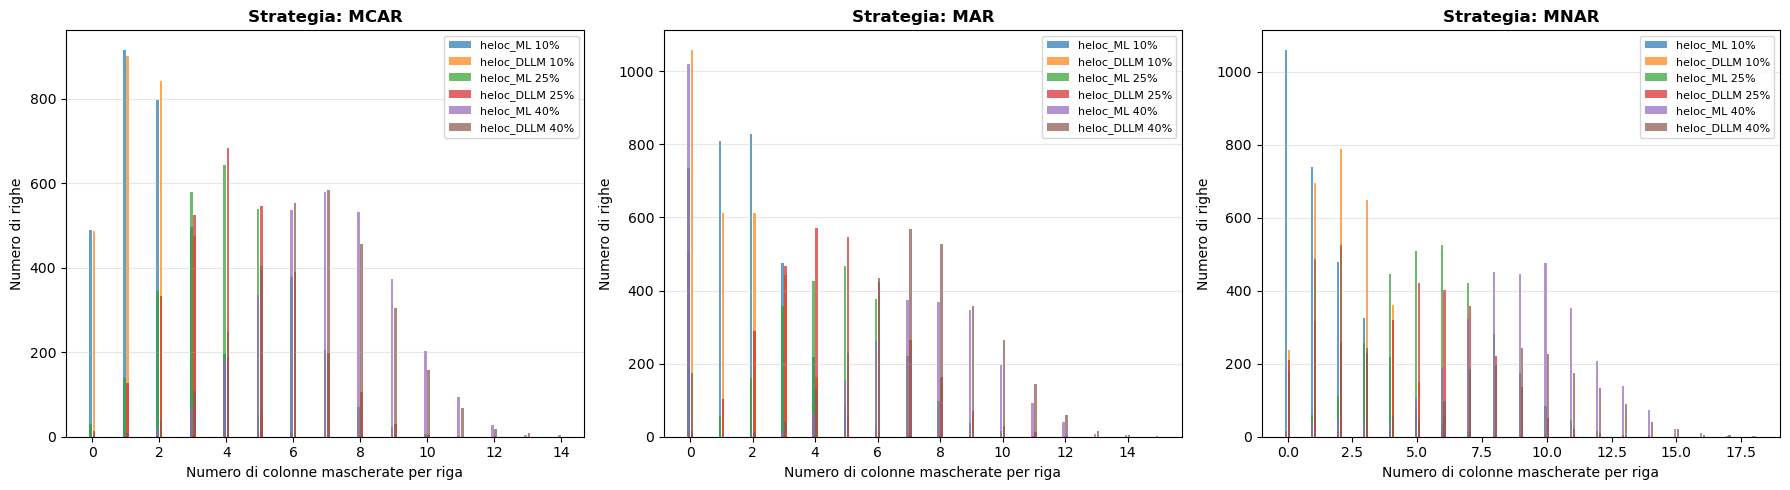

In [63]:
import matplotlib.pyplot as plt
from collections import Counter

# Carica i dati corrotti e le maschere
datasets = ['heloc_ML', 'heloc_DLLM']
strategies = ['MCAR', 'MAR', 'MNAR']
percentages = [0.10, 0.25, 0.40]

stats = []

for dataset in datasets:
    for strategy in strategies:
        for percentage in percentages:
            # Carica dati corrotti e maschera
            corrupted_file = f'../../data/processed/Fase2/DataCorruption/{dataset}/{dataset}_imputation_test_corrupted_{strategy.lower()}_{int(percentage*100)}.csv'
            mask_file = f'../../data/processed/Fase2/DataCorruption/{dataset}/{dataset}_imputation_test_mask_{strategy.lower()}_{int(percentage*100)}.csv'
            
            df_corrupted = pd.read_csv(corrupted_file)
            df_mask = pd.read_csv(mask_file)
            
            # Esclude la colonna target
            mask_data = df_mask.drop(columns=['RiskPerformance']).values
            
            n_rows, n_cols = mask_data.shape
            
            # Colonne oscurate
            cols_masked = np.sum(np.any(mask_data, axis=0))
            pct_cols_masked = 100 * cols_masked / n_cols
            
            # Righe oscurate
            rows_masked = np.sum(np.any(mask_data, axis=1))
            pct_rows_masked = 100 * rows_masked / n_rows
            
            # Distribuzione righe per numero di colonne mascherate
            cols_per_row = np.sum(mask_data, axis=1)
            row_dist = Counter(cols_per_row)
            
            stats.append({
                'dataset': dataset,
                'strategy': strategy,
                'percentage': percentage,
                'cols_masked': cols_masked,
                'pct_cols_masked': pct_cols_masked,
                'rows_masked': rows_masked,
                'pct_rows_masked': pct_rows_masked,
                'row_distribution': dict(row_dist)
            })

# Stampa statistiche
stats_df = pd.DataFrame([{**s, 'row_distribution': str(s['row_distribution'])} for s in stats])
print("Statistiche di granularità della corruzione:")
print(stats_df[['dataset', 'strategy', 'percentage', 'cols_masked', 'pct_cols_masked', 'rows_masked', 'pct_rows_masked']])

# Genera bar plot per strategia
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, strategy in enumerate(strategies):
    ax = axes[ax_idx]
    strategy_data = [s for s in stats if s['strategy'] == strategy]
    
    for pct_idx, percentage in enumerate(percentages):
        for ds_idx, dataset in enumerate(datasets):
            data = [s for s in strategy_data if s['dataset'] == dataset and s['percentage'] == percentage][0]
            row_dist = data['row_distribution']
            
            x_vals = sorted(row_dist.keys())
            y_vals = [row_dist[x] for x in x_vals]
            
            label = f"{dataset} {int(percentage*100)}%"
            offset = (ds_idx - 0.5) * 0.1
            ax.bar([x + offset for x in x_vals], y_vals, 
                   width=0.08, label=label, alpha=0.7)
    
    ax.set_xlabel('Numero di colonne mascherate per riga', fontsize=10)
    ax.set_ylabel('Numero di righe', fontsize=10)
    ax.set_title(f'Strategia: {strategy}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_dir = '../../data/processed/Fase1/Plot'
os.makedirs(plot_dir, exist_ok=True)
plot_path = os.path.join(plot_dir, 'corruption_distribution.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\nGrafico salvato: {plot_path}")
plt.show()
